# Step 5: Threshold & Trade-off Analysis

Every model built so far used a decision rule that's easy to forget is even a *choice*: "predict fraud if the model's estimated probability is above 50%." That 0.5 cutoff isn't a law of nature - it's a default, and Step 3 already hinted that it might not be the right one for a problem this imbalanced. This step treats the threshold as a dial to be tuned deliberately, not a fixed constant.

In [1]:
from data_prep import load_data, prepare_split
from sklearn.ensemble import RandomForestClassifier

df = load_data()
X_train, X_test, y_train, y_test = prepare_split(df)

rf_model = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_proba = rf_model.predict_proba(X_test)[:, 1]

## What does "threshold" actually mean here?

`predict_proba()` doesn't output "fraud" or "not fraud" - it outputs a probability, e.g. "this transaction is 73% likely to be fraud." Turning that into a yes/no decision requires picking a cutoff: above it, call it fraud; below it, don't. `predict()` uses 0.5 by default, but nothing forces that choice - lowering it makes the model flag more transactions as fraud (catching more real fraud, but also more false alarms); raising it makes the model more conservative (fewer false alarms, but more real fraud slips through).

## The precision-recall curve

Plots precision against recall as the threshold sweeps from very strict (high threshold, top-left) to very lenient (low threshold, bottom-right) - the whole trade-off, visualized at once, instead of picking one threshold and reporting a single number.

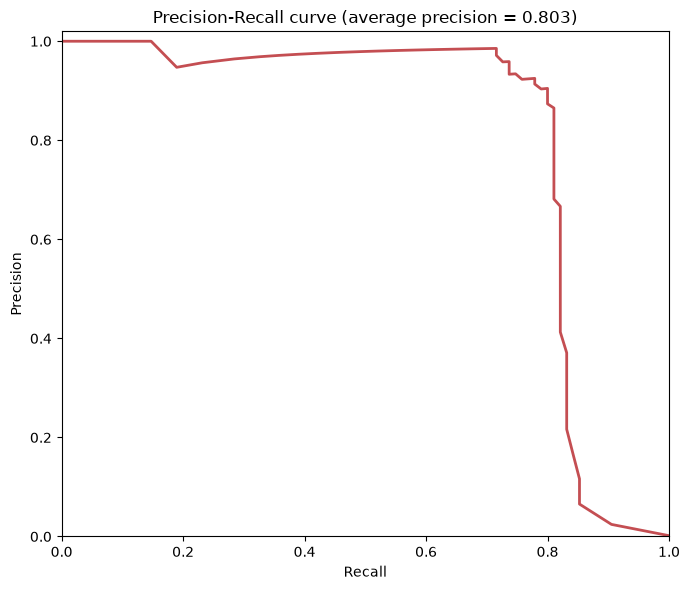

In [2]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(recalls, precisions, color="#C44E52", lw=2)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(f"Precision-Recall curve (average precision = {avg_precision:.3f})")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.savefig("assets/precision_recall_curve.png", dpi=120)
plt.show()

The curve stays high (both precision and recall above ~0.7) for a wide stretch before dropping sharply - a sign this model has genuinely learned to separate the classes well, not just gotten lucky at one specific cutoff.

## Trying specific thresholds

In [3]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

rows = []
for t in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    y_pred_t = (y_proba >= t).astype(int)
    rows.append({
        "threshold": t,
        "precision": precision_score(y_test, y_pred_t),
        "recall": recall_score(y_test, y_pred_t),
        "f1": f1_score(y_test, y_pred_t),
    })

threshold_table = pd.DataFrame(rows).round(3)
threshold_table

,threshold,precision,recall,f1
0,0.1,0.733,0.811,0.770
1,0.2,0.856,0.811,0.832
2,0.3,0.914,0.779,0.841
3,0.4,0.933,0.737,0.824
4,0.5,0.958,0.726,0.826
5,0.6,0.958,0.726,0.826
6,0.7,0.985,0.695,0.815
7,0.8,0.984,0.653,0.785
8,0.9,0.981,0.537,0.694


The default 0.5 isn't the best F1 in this table - 0.3 does better (precision 91.4%, recall 77.9%, F1 0.841 vs. 0.5's F1 of 0.826). Worth finding the actual best point precisely, not just among these nine round numbers.

## Finding the F1-optimal threshold

In [4]:
import numpy as np

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores[:-1])  # last point in the curve has no corresponding threshold
best_threshold = thresholds[best_idx]

print(f"Best threshold for F1: {best_threshold:.3f}")
print(f"Precision at this threshold: {precisions[best_idx]*100:.1f}%")
print(f"Recall at this threshold:    {recalls[best_idx]*100:.1f}%")
print(f"F1 at this threshold:        {f1_scores[best_idx]:.3f}")
print()
print(f"Compare to default threshold 0.5: F1 = 0.826")

Best threshold for F1: 0.255
Precision at this threshold: 90.5%
Recall at this threshold:    80.0%
F1 at this threshold:        0.849

Compare to default threshold 0.5: F1 = 0.826


Lowering the threshold from the default 0.5 to **0.255** raises F1 from 0.826 to **0.849**: precision drops modestly (95.8% -> 90.5%) but recall climbs meaningfully (72.6% -> 80.0%) - catching 7-8 more real fraud cases out of every 95, for a handful of extra false alarms. Simply not blindly trusting `predict()`'s default cutoff was worth a real, measurable improvement, with no retraining needed at all.

## The business decision this table doesn't answer for you

F1 treats a false positive and a false negative as equally bad, weighted only by how it affects precision and recall symmetrically. **A real fraud team usually shouldn't stop at "whichever threshold maximizes F1"** - the actual costs aren't symmetric:

- **A false positive** (flagging a legitimate transaction) usually costs a minor inconvenience: a text message to confirm, maybe a temporarily declined card.
- **A false negative** (missing real fraud) costs the actual stolen money, plus investigation and reputational cost.

When the cost of missing fraud is that much higher than the cost of a false alarm, a bank might deliberately choose a **lower threshold than even the F1-optimal one** - accepting more false alarms in exchange for catching more fraud - as long as the false-alarm volume doesn't become operationally unmanageable for whoever reviews the flagged transactions. There's no single "correct" threshold in the abstract; the right choice depends on these real-world costs, which this dataset alone can't tell us. What this analysis *can* do is hand a decision-maker the full curve and a clear picture of what's traded for what at each point - rather than silently picking 0.5 and calling it done.

## Summary

- The 0.5 default threshold is an arbitrary starting point, not a correct answer - especially for a severely imbalanced problem like this one.
- The precision-recall curve shows the full trade-off at once; the F1-optimal threshold here is **0.255** (precision 90.5%, recall 80.0%, F1 0.849), a real improvement over the default with zero retraining required.
- **F1-optimal isn't automatically business-optimal** - the right threshold depends on how costly a missed fraud case is relative to a false alarm, a judgment call outside what the data alone can answer.

This closes out the modeling work. Step 6 writes up the whole project - from the imbalance problem in Step 1 to this threshold decision - as a README a hiring manager can actually follow.